## 1. Introduction
This project explores the customer data to understand customer geographic distribution,
customer segment and customer acquisition cost.
The analysis uses Python and libraries such as Pansdas, NumPy, Matplotlib, and Seaborn to perform exploratory data analysis (EDA). 

## 2. Loading libraries and dataset

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("customer_master.csv")


## 3 Data overview:



 ### 3.1 Dataset dimensions

In [46]:
df.shape

(25000, 11)

## 3.2  Data types and non-null values


In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                25000 non-null  str    
 1   customer_name              25000 non-null  str    
 2   customer_age               25000 non-null  int64  
 3   gender                     25000 non-null  str    
 4   customer_segment           25000 non-null  str    
 5   customer_city              25000 non-null  str    
 6   customer_state             25000 non-null  str    
 7   customer_country           25000 non-null  str    
 8   region                     25000 non-null  str    
 9   customer_postal_code       25000 non-null  int64  
 10  customer_acquisition_cost  25000 non-null  float64
dtypes: float64(1), int64(2), str(8)
memory usage: 2.1 MB


## 3.3 Missing values:


In [48]:
df.isnull().sum()

customer_id                  0
customer_name                0
customer_age                 0
gender                       0
customer_segment             0
customer_city                0
customer_state               0
customer_country             0
region                       0
customer_postal_code         0
customer_acquisition_cost    0
dtype: int64

## 3.4 Duplicate records:


In [49]:
df.duplicated().sum()

np.int64(0)

## 3.5 Descriptive and statistics


In [50]:
df.describe()

,customer_age,customer_postal_code,customer_acquisition_cost
count,25000.000000,25000.000000,25000.000000
mean,45.907840,50183.066400,42.159750
std,16.454286,28596.584321,21.692648
min,18.000000,516.000000,5.010000
25%,32.000000,25374.500000,23.297500
50%,46.000000,50303.000000,41.980000
75%,60.000000,74845.500000,61.130000
max,74.000000,99950.000000,79.990000


## 3.6 Data sample


In [51]:
df.sample(5)

,customer_id,customer_name,customer_age,gender,customer_segment,customer_city,customer_state,customer_country,region,customer_postal_code,customer_acquisition_cost
16968,CUST-016969,Jennifer Wright,21,Male,Premium,Gonzalezhaven,Wales,UK,West,88236,57.07
22355,CUST-022356,Kerry Jackson,34,Male,VIP,Lake Cindy,Illinois,USA,Central,71329,46.03
19865,CUST-019866,Anthony Prince,50,Male,Business,East Kimberly,California,USA,West,10517,31.48
17669,CUST-017670,Mackenzie Murray,32,Male,Premium,New Nathanborough,California,USA,West,16968,60.95
3597,CUST-003598,Patrick Burns,53,Male,Business,South Jeffery,Ontario,Canada,East,74898,30.42


## 4. Country Analysis

In [52]:
grouped=df.groupby("customer_country", as_index=False).agg(
    total_customer=("customer_id", "count"),
    avg_cost=("customer_acquisition_cost", "mean"),
    avg_age=("customer_age", "mean")
)
grouped["cust_pct"]=(grouped["total_customer"]/grouped["total_customer"].sum())*100

## 4.1 Customer Distribution by Country

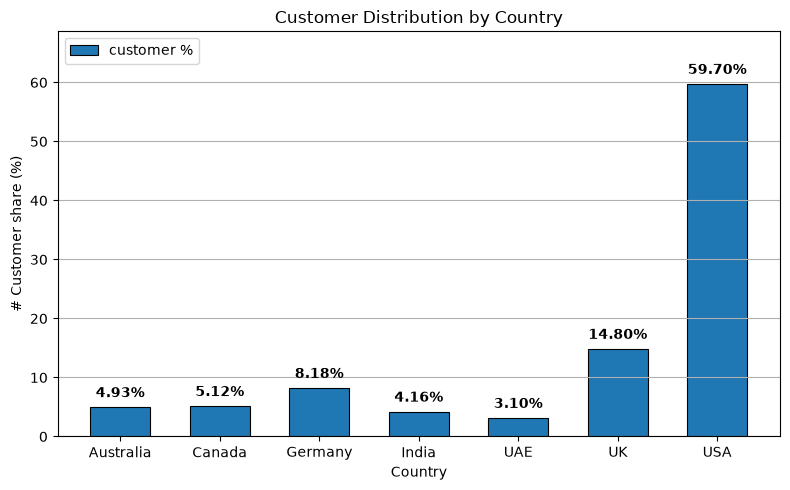

In [53]:
fig, ax=plt.subplots(1, 1, figsize=(8,5))
ax.set_ylim(0, max(grouped["cust_pct"])*1.15)
bar=ax.bar(grouped["customer_country"],
            grouped["cust_pct"],
            width=0.6,
            label="customer %",
            edgecolor="black",
            linewidth=0.8)
ax.set_title("Customer Distribution by Country")
ax.set_xlabel("Country")
ax.set_ylabel("# Customer share (%)")
plt.tight_layout()
ax.bar_label(bar, fmt="%.2f%%", padding=5, fontsize=10, weight="bold")
plt.grid(axis="y")
plt.legend(loc="upper left")

## 4.2 Average acquisition cost by country

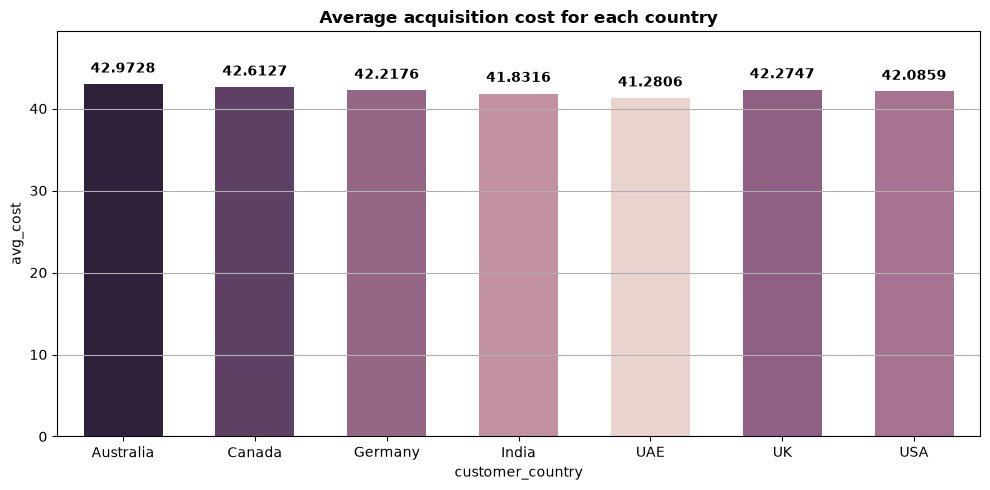

In [54]:
fig, ax= plt.subplots(1,1, figsize=(10,5))
ax.set_ylim(0, grouped["avg_cost"].max()*1.15)

bar=sns.barplot(data=grouped,
                x="customer_country",
                y="avg_cost",
                width=0.6, ax=ax, hue="avg_cost", legend=False)

for x in ax.containers:
    ax.bar_label(x, padding=6, weight="bold")

ax.set_title("Average acquisition cost for each country", weight="bold")
plt.tight_layout()
plt.grid(axis="y")

## 4.3 Average customer age by each country

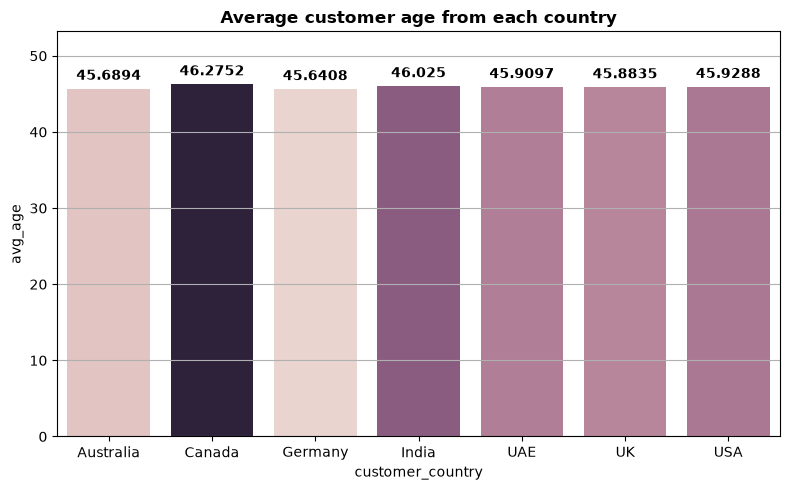

In [55]:
fig, ax= plt.subplots(1,1, figsize=(8,5))
ax.set_ylim(0, grouped["avg_age"].max()*1.15)

sns.barplot( data=grouped,
            x="customer_country",
            y="avg_age",
            hue="avg_age", legend=False)

for x in ax.containers:
    ax.bar_label(x, padding=4, weight="bold")

ax.set_title("Average customer age from each country", weight="bold")
plt.grid(axis='y')
plt.tight_layout()

## 5. Age & Acquisition analysis

  ### 5.1 Correlation

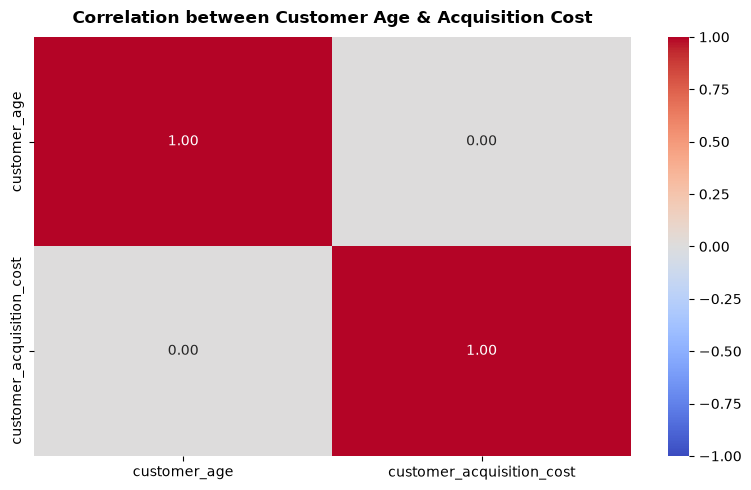

In [56]:

fig, ax= plt.subplots(figsize=(8,5))
columns=["customer_age", "customer_acquisition_cost"]
corr_matrix=df[columns].corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            vmin=-1, vmax=1, ax=ax)

ax.set_title("Correlation between Customer Age & Acquisition Cost", weight="bold", pad=10)
plt.tight_layout()


## 5.2 Age distribution

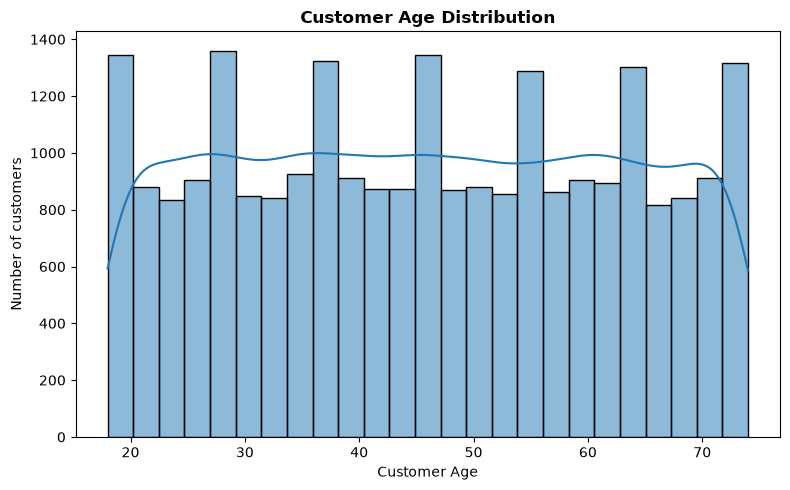

In [57]:
fig, ax=plt.subplots(figsize=(8,5))
sns.histplot(data=df,
             x="customer_age",
             bins=25,
             kde=True,
             ax=ax)

ax.set_title("Customer Age Distribution", weight="bold")
ax.set_xlabel("Customer Age")
ax.set_ylabel("Number of customers")

plt.tight_layout()

## 6. Customer distribution by Region

Region-wise contribution for each country
 region            Central  East  North  South  West  Total
customer_country                                          
Australia               0   252    191    536   254   1233
Canada                525   473      0      0   281   1279
Germany               415     0    397    804   430   2046
India                   0     0    223    424   394   1041
UAE                     0     0    371    404     0    775
UK                      0     0   1840      0  1861   3701
USA                  4418  3149      0   5828  1530  14925
Total                5358  3874   3022   7996  4750  25000


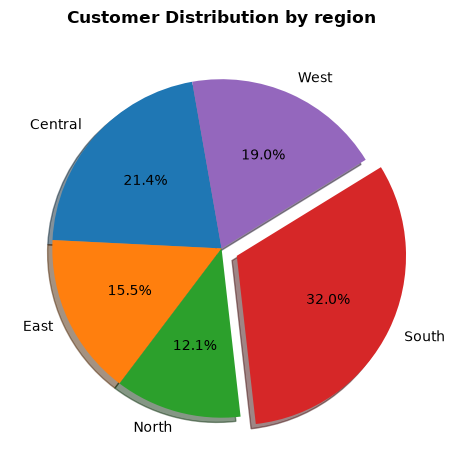

In [58]:
by_region=pd.crosstab(index=df["customer_country"],
                      columns=df["region"],
                      margins=True, margins_name="Total")
print("Region-wise contribution for each country\n",by_region)

each_region=df.groupby("region")["customer_id"].count()
max_index=each_region.values.argmax()
exploding_values=[0.1 if i==max_index else 0 for i in range(len(each_region))]

plt.pie(each_region,
        labels=each_region.index,
        explode=exploding_values,
        shadow=True,
        autopct="%.1f%%",
        startangle=100)

plt.title("Customer Distribution by region", weight="bold", pad=10)
plt.tight_layout()


## 7. Average acquisition cost for each customer segment

C:\Users\anil2\AppData\Local\Temp\ipykernel_18912\941497286.py:6: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1A2CD2'` for the same effect.

  sns.barplot(x=by_segment.index,


Text(0.5, 1.0, ' Average acquisition cost by customer segment')

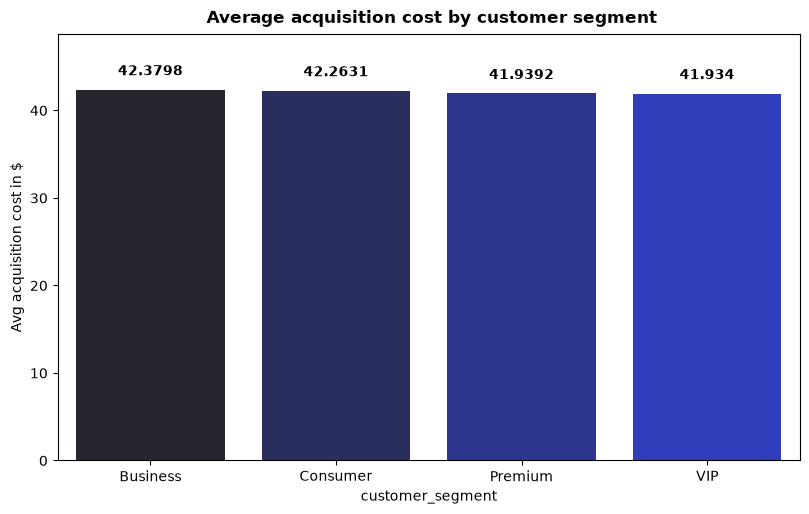

In [59]:
by_segment=df.groupby("customer_segment")["customer_acquisition_cost"].mean()

fig, ax=plt.subplots(figsize=(8,5))
ax.set_ylim(0, by_segment.values.max()*1.15)

sns.barplot(x=by_segment.index,
            y=by_segment.values,
            hue=by_segment.index, color="#1A2CD2")

for x in ax.containers:
    ax.bar_label(x, weight="bold", padding=8)

plt.tight_layout()
ax.set_ylabel("Avg acquisition cost in $")
ax.set_title(" Average acquisition cost by customer segment", weight="bold", pad=8)


## 8. Number of customers from each segment

C:\Users\anil2\AppData\Local\Temp\ipykernel_18912\790083022.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


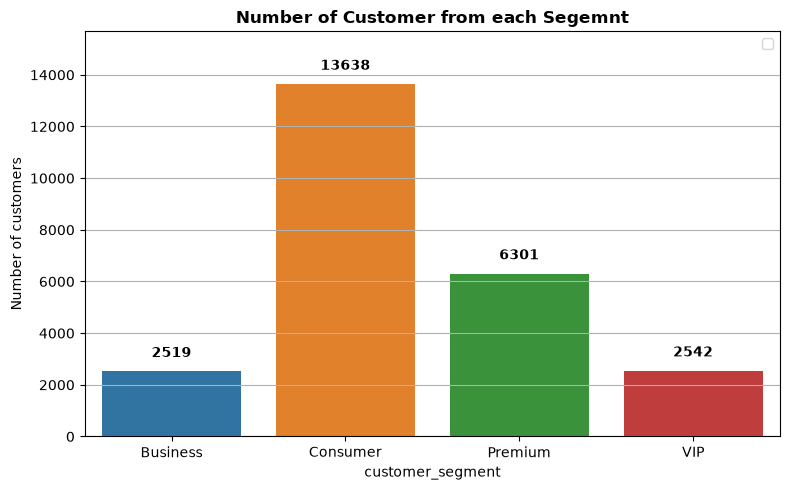

In [60]:
fig, ax= plt.subplots(figsize=(8,5))

segment_size=df.groupby("customer_segment").size()
ax.set_ylim(0, segment_size.max()*1.15)

sns.barplot(x=segment_size.index,
            y=segment_size.values,
            hue=segment_size.index)

ax.set_ylabel("Number of customers")
ax.set_title("Number of Customer from each Segemnt", weight="bold")

for x in ax.containers:
    ax.bar_label(x, padding=8, weight="bold")

plt.tight_layout()
plt.legend()
plt.grid(axis="y")

## 9. Top 10 States by Customer Count

C:\Users\anil2\AppData\Local\Temp\ipykernel_18912\1076359210.py:7: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:blue'` for the same effect.

  sns.barplot( data=top10,


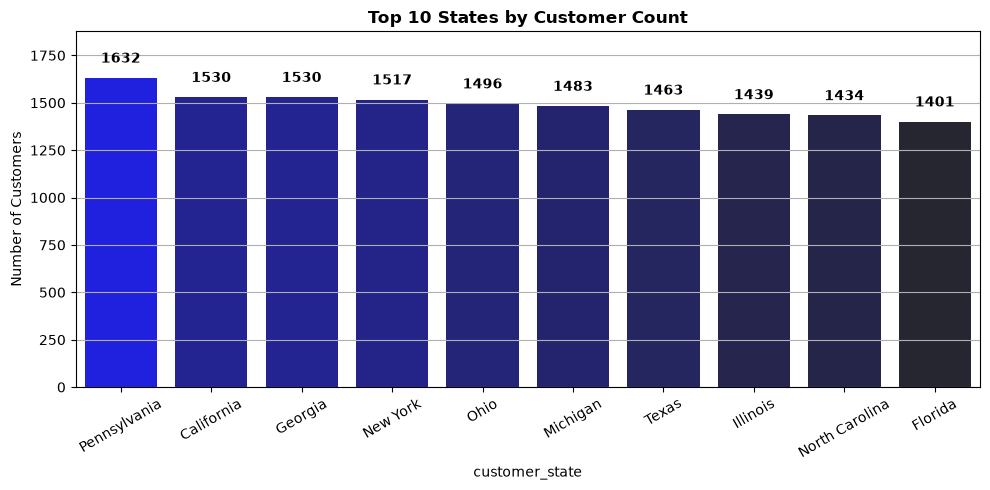

In [61]:
state_wise=df.groupby("customer_state").agg(total=("customer_state", "count"))
top10=state_wise.nlargest(10, "total")

fig, ax=plt.subplots(figsize=(10,5))
ax.set_ylim(0, state_wise["total"].max()*1.15)

sns.barplot( data=top10,
            x=top10.index,
            y=top10["total"],
            hue=top10["total"], color="blue", legend=False)

for x in ax.containers:
    ax.bar_label(x, weight="bold", padding=8.5)

ax.set_ylabel("Number of Customers")
ax.tick_params(axis="x", rotation=30)
ax.set_title("Top 10 States by Customer Count", weight="bold")
plt.tight_layout()
plt.grid(axis="y")



## 10. Key findings:

1. USA contributes highest number of cusotomers about 59.70% of total customers.
2. Average acquisition cost is relatively similar accross countries (~ 41-42)
3. Southern region constributes highest number of customer (~ 32.0%).
4. Consumer segment has highest number of customers which is 13638 while business segment has the lowest which is 2519.
5. Pennsylvania has the highest customer concentration among individual states in the dataset, with approximately 1632        
   customers

## 11. Conclusion:

Through exploratory data analysis and visualization, several patterns were identifeid in customer distribution across countries, regions, sates, segments and age groups. The analysis also examined how customer acquisition cost vary across different customer groups and countries. 